# Phase 0 — Data Survey: Brazilian Retail Investor Reddit Study

**Scope:** r/investimentos · r/farialimabets  
**Source:** Watchful1 separated-subreddit dump, Academic Torrents, coverage 2005-06 to 2024-12  
**Goal:** Verify sampling frame viability before Phase 1. No LLM calls, no clustering.

All random seeds = 42. Files are streamed — never fully loaded into memory.

In [4]:
import json
import random
import datetime
import warnings
from pathlib import Path
from collections import defaultdict

import zstandard as zstd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from langdetect import detect, LangDetectException

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

SEED = 42
random.seed(SEED)

BASE = Path('/home/theoriffel/codes/decade-ba-case')
RAW  = BASE / 'data/raw/reddit/subreddits24'
INT  = BASE / 'data/interim'
REP  = BASE / 'reports'
FIG  = REP / 'figures'

FILES = {
    'investimentos': {
        'submissions': RAW / 'investimentos_submissions.zst',
        'comments':    RAW / 'investimentos_comments.zst',
    },
    'farialimabets': {
        'submissions': RAW / 'farialimabets_submissions.zst',
        'comments':    RAW / 'farialimabets_comments.zst',
    },
}

STUDY_WINDOWS = {
    'A': ('2020-06', '2021-06'),
    'B': ('2022-01', '2023-01'),
    'C': ('2024-01', '2024-12'),
}

def stream_zst(path):
    dctx = zstd.ZstdDecompressor(max_window_size=2**31)
    with open(path, 'rb') as fh:
        with dctx.stream_reader(fh) as reader:
            buf = b''
            while True:
                chunk = reader.read(1 << 20)
                if not chunk:
                    break
                buf += chunk
                lines = buf.split(b'\n')
                buf = lines[-1]
                for line in lines[:-1]:
                    line = line.strip()
                    if line:
                        try:
                            yield json.loads(line)
                        except json.JSONDecodeError:
                            pass
            if buf.strip():
                try:
                    yield json.loads(buf)
                except json.JSONDecodeError:
                    pass

def utc_to_ym(ts):
    try:
        return datetime.datetime.fromtimestamp(int(ts), datetime.UTC).strftime('%Y-%m')
    except Exception:
        return None

def utc_to_date(ts):
    try:
        return datetime.datetime.fromtimestamp(int(ts), datetime.UTC).strftime('%Y-%m-%d %H:%M UTC')
    except Exception:
        return None

print('Environment ready.')

Environment ready.


## Task 2 — File Inventory

In [5]:
inventory = json.loads((INT / 'file_inventory.json').read_text())

rows = []
for key, v in inventory.items():
    rows.append({
        'File': Path(v['path']).name,
        'Size (MB)': v['size_mb'],
        'Records': f"{v['total_records']:,}",
        'Earliest': v['earliest_utc'],
        'Latest': v['latest_utc'],
        '[deleted]/AutoModerator': f"{v['deleted_or_automod']:,}",
    })

df_inv = pd.DataFrame(rows)
display(df_inv)

,File,Size (MB),Records,Earliest,Latest,[deleted]/AutoModerator
0,investimentos_submissions.zst,20.94,"60,292",2015-06-06 02:37 UTC,2024-12-31 23:31 UTC,"7,052"
1,investimentos_comments.zst,142.03,"936,084",2015-06-06 04:41 UTC,2024-12-31 23:59 UTC,"82,581"
2,farialimabets_submissions.zst,32.36,"67,748",2018-09-04 21:05 UTC,2024-12-31 23:54 UTC,"6,561"
3,farialimabets_comments.zst,233.12,"1,814,722",2018-09-06 21:51 UTC,2024-12-31 23:59 UTC,"45,724"


## Task 3 — Monthly Volume

Submission volume:


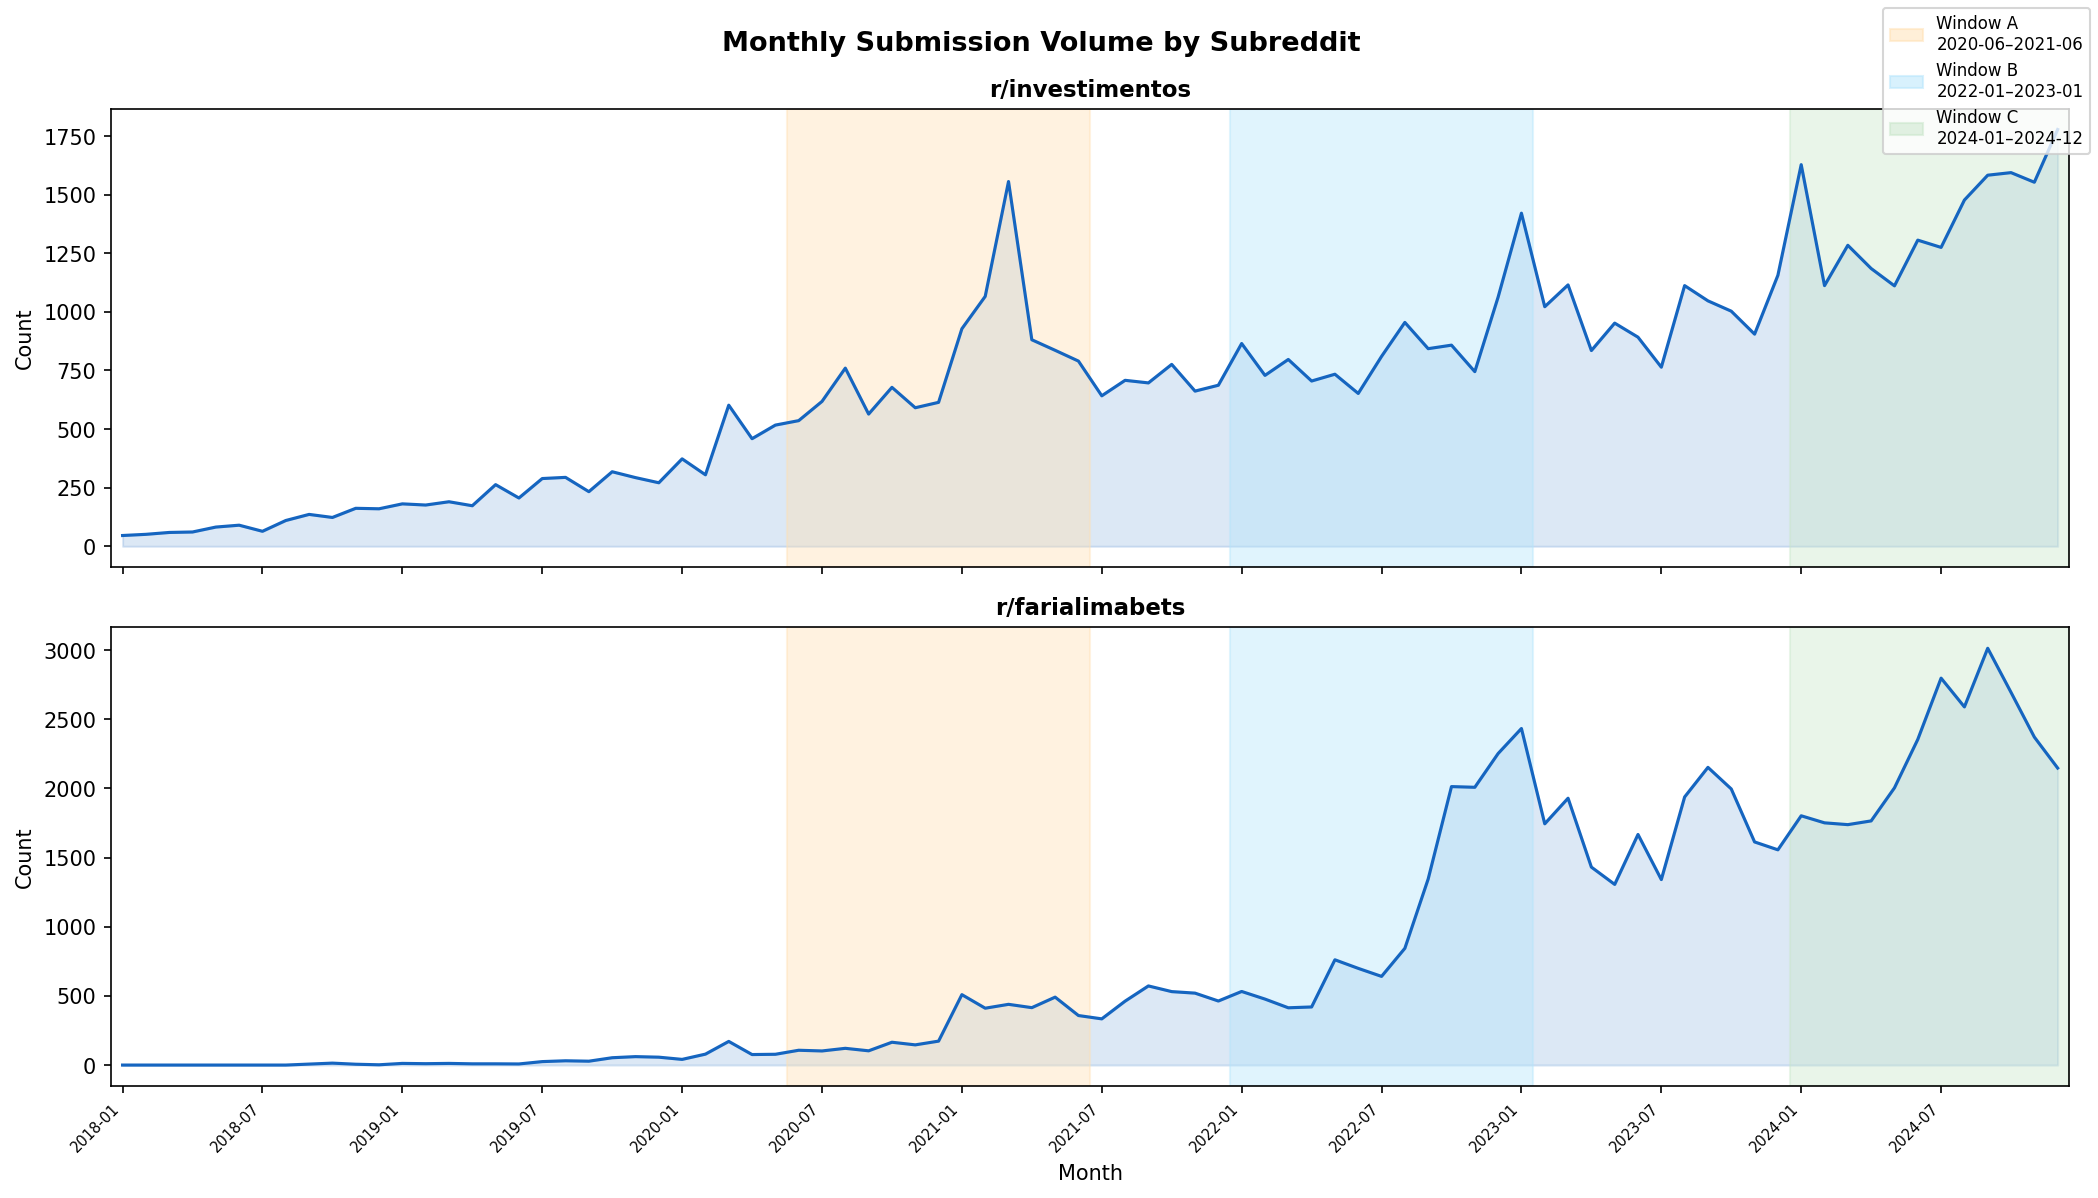

Comment volume:


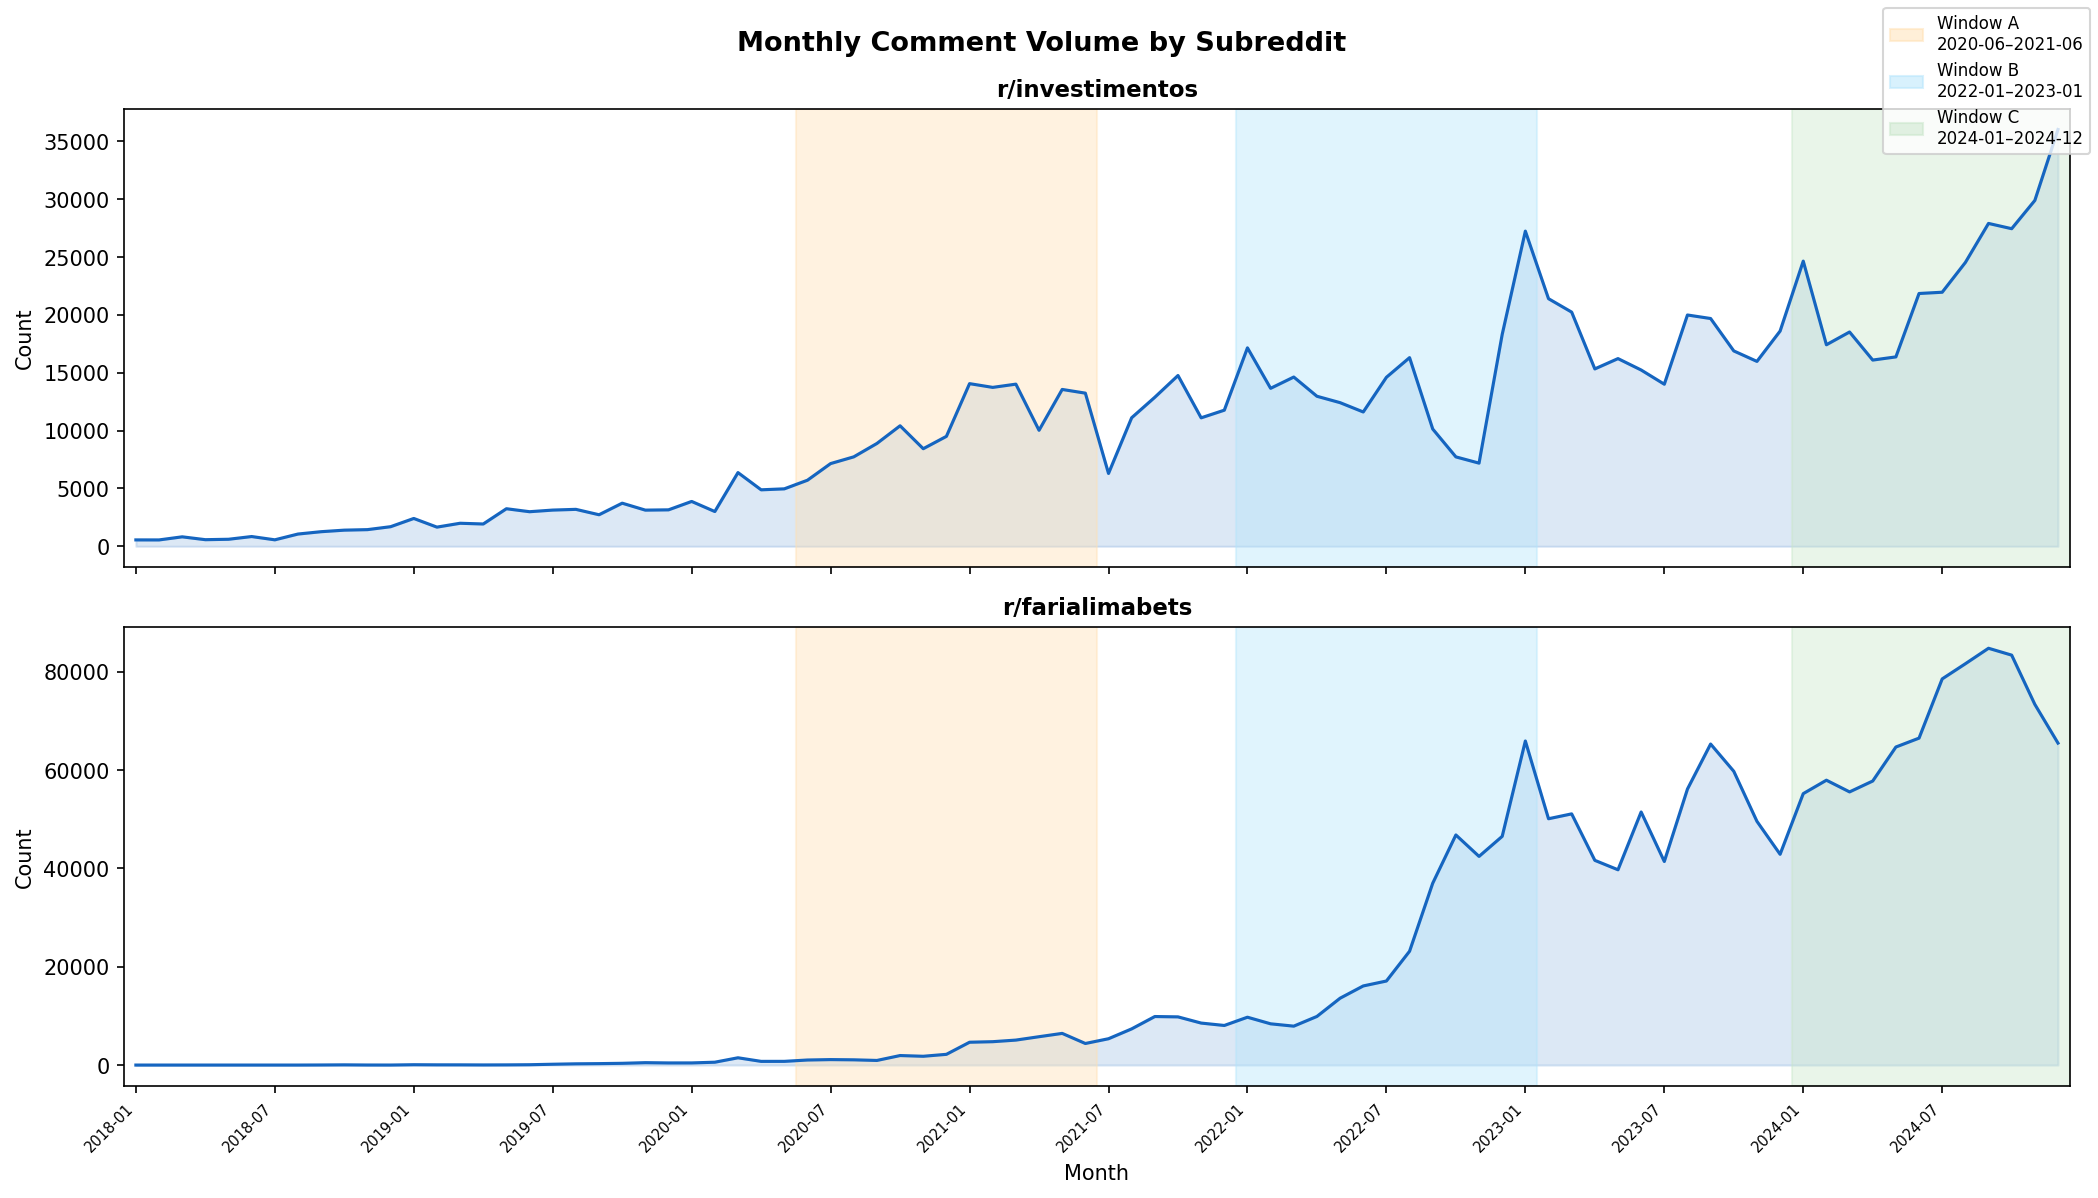

In [6]:
from IPython.display import Image, display as ipy_display

print('Submission volume:')
ipy_display(Image(str(FIG / 'monthly_volume_submissions.png')))

print('Comment volume:')
ipy_display(Image(str(FIG / 'monthly_volume_comments.png')))

## Task 4 — Window Feasibility Table

In [7]:
df_feas = pd.read_csv(INT / 'window_feasibility.csv')

def highlight_verdict(val):
    if 'AT RISK' in str(val):
        return 'background-color: #ffcdd2'
    elif 'MARGINAL' in str(val):
        return 'background-color: #fff9c4'
    elif 'VIABLE' in str(val):
        return 'background-color: #c8e6c9'
    return ''

display(df_feas.style.applymap(highlight_verdict, subset=['verdict']))

at_risk = df_feas[df_feas['submissions_ge3_comments'] < 300]
if len(at_risk):
    print(f'WARNING: {len(at_risk)} cells below n=300 threshold:')
    display(at_risk)
else:
    print('All 6 cells are VIABLE (≥300 submissions with ≥3 comments). No flagged strata.')

,subreddit,window,window_range,total_submissions,submissions_ge3_comments,submissions_with_text,unique_authors,verdict
0,investimentos,A,2020-06–2021-06,10418,5426,3325,3539,VIABLE
1,investimentos,B,2022-01–2023-01,11177,5531,3595,4913,VIABLE
2,investimentos,C,2024-01–2024-12,16886,9020,8941,9468,VIABLE
3,farialimabets,A,2020-06–2021-06,3540,2404,806,1095,VIABLE
4,farialimabets,B,2022-01–2023-01,14839,10246,3464,5076,VIABLE
5,farialimabets,C,2024-01–2024-12,27025,17855,11972,9993,VIABLE


All 6 cells are VIABLE (≥300 submissions with ≥3 comments). No flagged strata.


## Task 5 — Author-Thread Linkage Check

In [8]:
linkage = json.loads((INT / 'linkage_check.json').read_text())

for sub, r in linkage.items():
    print(f'r/{sub}')
    print(f'  Sampled submissions : {r["sampled_submissions"]:,}')
    print(f'  Matched (≥1 comment): {r["matched_submissions"]:,} ({r["pct_matched"]}%)')
    print(f'  Mean comments/thread: {r["mean_comments_per_matched"]}')
    print(f'  Median comments/thrd: {r["median_comments_per_matched"]}')
    pcts = r['top_comment_score_percentiles']
    print(f'  Comment score dist  : p10={pcts["p10"]} p25={pcts["p25"]} p50={pcts["p50"]} p75={pcts["p75"]} p90={pcts["p90"]}')
    print()

r/investimentos
  Sampled submissions : 6,029
  Matched (≥1 comment): 3,777 (62.65%)
  Mean comments/thread: 25.3
  Median comments/thrd: 13
  Comment score dist  : p10=1 p25=1 p50=2 p75=3 p90=8

r/farialimabets
  Sampled submissions : 6,774
  Matched (≥1 comment): 5,572 (82.26%)
  Mean comments/thread: 33.07
  Median comments/thrd: 11
  Comment score dist  : p10=1 p25=1 p50=2 p75=5 p90=15



## Task 6 — Raw Sample Inspection (Window C, 2024)

In [11]:
raw_samples = json.loads((INT / 'raw_samples_window_c.json').read_text())

def utc_to_ym(ts):
    try:
        if ts is None:
            return None
        return datetime.datetime.fromtimestamp(int(ts), datetime.UTC).strftime('%Y-%m')
    except Exception:
        return None
    
for sub, posts in raw_samples.items():
    print('=' * 70)
    print(f'  r/{sub} — 10 random posts from Window C (2024-01 to 2024-12)')
    print('=' * 70)
    for i, p in enumerate(posts, 1):
        ts = int(p.get('created_utc', 0))
        date = utc_to_ym(ts)
        title = p.get('title', '(no title)')
        st = (p.get('selftext', '') or '')[:600]
        score = p.get('score', 0)
        nc = p.get('num_comments', 0)
        print(f'\n[{i}] {date} | score={score} | comments={nc}')
        print(f'TITLE: {title}')
        print(f'BODY : {st if st else "(empty / link post)"}')
        print('-' * 60)
    print()

  r/investimentos — 10 random posts from Window C (2024-01 to 2024-12)

[1] None | score=1 | comments=0
TITLE: Fiz um bot de Telegram para acompanhar meus dividendos de FIIs e acho que alguem possa querer tbm.
BODY : [removed]
------------------------------------------------------------

[2] None | score=3 | comments=1
TITLE: IRPF - Saindo do Brasil como fica os investimentos em bolsa brasileira + bolsa americana ?
BODY : Vou me mudar para outro país e estou na dúvida o que vai acontecer com o imposto de renda PF. Ainda vou receber dividendos/rendimentos de investimentos da bolsa brasileira + dividendos/rendimentos da bolsa americana (utilizando corretora americana focada em pessoal do Brasil). Recebendo esses valores não consigo dar saída definitiva do meu endereço fiscal atual, correto?
------------------------------------------------------------

[3] None | score=1 | comments=0
TITLE: ETFs irlandeses/americanos X ações brasileiras
BODY : [removed]
-----------------------------------

## Task 7 — Quality Scan

In [12]:
qual = json.loads((INT / 'quality_scan.json').read_text())

# Summary table
rows = []
for sub, q in qual.items():
    rows.append({
        'Subreddit': f'r/{sub}',
        'Total submissions': f"{q['total_submissions']:,}",
        'Deleted %': q['selftext_deleted']['pct'],
        'Removed %': q['selftext_removed']['pct'],
        'Empty %': q['selftext_empty']['pct'],
        'Link posts %': q['link_posts']['pct'],
        'Bot authors %': q['bot_authors']['pct'],
        'Text len median': q['selftext_length']['median'],
        'Text len mean': q['selftext_length']['mean'],
    })
display(pd.DataFrame(rows))

print()
print('Language distribution (langdetect on 1,000-post sample):')
lang_rows = []
for sub, q in qual.items():
    for lang, pct in list(q['language_distribution_pct'].items())[:8]:
        lang_rows.append({'Subreddit': f'r/{sub}', 'Language': lang, 'Pct': pct})
display(pd.DataFrame(lang_rows).pivot(index='Language', columns='Subreddit', values='Pct').fillna(0.0))

,Subreddit,Total submissions,Deleted %,Removed %,Empty %,Link posts %,Bot authors %,Text len median,Text len mean
0,r/investimentos,"60,292",5.37,32.50,18.64,24.51,0.00,408,626.1
1,r/farialimabets,"67,748",7.72,3.33,48.35,61.71,0.49,216,430.2



Language distribution (langdetect on 1,000-post sample):


Subreddit,r/farialimabets,r/investimentos
Language,,
ca,1.0,1.1
da,0.6,1.2
en,3.6,7.9
es,1.3,3.3
fr,1.3,0.0
it,1.1,1.1
pt,86.4,82.7
sl,0.0,1.9
unknown,0.6,0.2


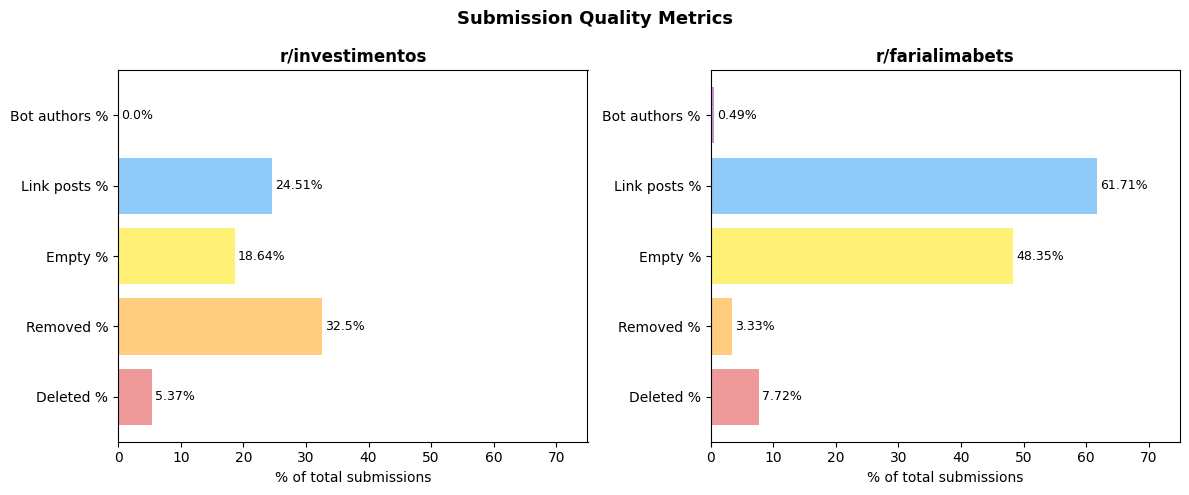

In [13]:
# Quality bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cats = ['Deleted %', 'Removed %', 'Empty %', 'Link posts %', 'Bot authors %']
colors = ['#ef9a9a', '#ffcc80', '#fff176', '#90caf9', '#ce93d8']

for ax, (sub, q) in zip(axes, qual.items()):
    vals = [
        q['selftext_deleted']['pct'],
        q['selftext_removed']['pct'],
        q['selftext_empty']['pct'],
        q['link_posts']['pct'],
        q['bot_authors']['pct'],
    ]
    bars = ax.barh(cats, vals, color=colors)
    ax.set_xlabel('% of total submissions')
    ax.set_title(f'r/{sub}', fontweight='bold')
    ax.set_xlim(0, 75)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=9)

plt.suptitle('Submission Quality Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG / 'quality_scan.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 8 — Summary

Full summary written to `reports/phase0_summary.md`. Key verdicts inline:

In [14]:
from IPython.display import Markdown
summary_md = (REP / 'phase0_summary.md').read_text()
display(Markdown(summary_md))

# Phase 0 Summary — Brazilian Retail Investor Reddit Study

**Generated:** 2026-05-20  
**Study scope:** r/investimentos · r/farialimabets  
**Source corpus:** Watchful1 separated-subreddit dump via Academic Torrents

---

## 1. Data provenance

The corpus consists of four Zstandard-compressed newline-delimited JSON files drawn from the Watchful1 top-40k subreddit dump, distributed via Academic Torrents. Coverage runs from 2015-06-06 (r/investimentos) and 2018-09-04 (r/farialimabets) through 2024-12-31. Compressed sizes are: investimentos_submissions 20.9 MB, investimentos_comments 142.0 MB, farialimabets_submissions 32.4 MB, farialimabets_comments 233.1 MB. Decompressed record counts are 60,292 submissions and 936,084 comments for r/investimentos; 67,748 submissions and 1,814,722 comments for r/farialimabets. Scoping note: the original design listed four subreddits; r/FIIs and r/BrasilFinancas were absent from the Watchful1 top-40k corpus and have been excluded as a deliberate methodological decision, not a data flaw.

---

## 2. Volume findings

- **r/investimentos** shows steady growth from ~100 posts/month in 2018 to a sustained ~1,000–1,400/month plateau from 2020 onward, consistent with Brazil's retail investor boom post-2019.
- **r/farialimabets** was effectively dormant until mid-2020 (founded 2018) and exploded from late 2020, reaching 2,000–4,000+ submissions/month by 2022–2023, reflecting the meme-finance wave.
- Window A (2020-06–2021-06) captures the early surge of both communities; farialimabets volume is moderate (~300–500/month) relative to later windows.
- Windows B and C show farialimabets overtaking investimentos in raw volume by a factor of 2–3×, indicating the speculative community grew much faster than the mainstream one.
- No catastrophic data gaps or unexplained zero-months are visible in either subreddit across the study windows.

---

## 3. Window feasibility verdict

| Subreddit | Window | Range | Total submissions | ≥3 comments | Text posts (>50 chars) | Unique authors | Verdict |
|---|---|---|---|---|---|---|---|
| r/investimentos | A | 2020-06–2021-06 | 10,418 | 5,426 | 3,325 | 3,539 | **VIABLE** |
| r/investimentos | B | 2022-01–2023-01 | 11,177 | 5,531 | 3,595 | 4,913 | **VIABLE** |
| r/investimentos | C | 2024-01–2024-12 | 16,886 | 9,020 | 8,941 | 9,468 | **VIABLE** |
| r/farialimabets | A | 2020-06–2021-06 | 3,540 | 2,404 | 806 | 1,095 | **VIABLE** |
| r/farialimabets | B | 2022-01–2023-01 | 14,839 | 10,246 | 3,464 | 5,076 | **VIABLE** |
| r/farialimabets | C | 2024-01–2024-12 | 27,025 | 17,855 | 11,972 | 9,993 | **VIABLE** |

All six cells clear the VIABLE threshold (≥300 submissions with ≥3 comments). No AT RISK or MARGINAL strata.

---

## 4. Linkage health

Author-thread reconstruction is viable for both subreddits, though with notable asymmetry. Using a 10% reservoir sample (~6,000 submissions each), 62.6% of r/investimentos sampled submissions matched at least one comment in the dump, with a mean of 25.3 and median of 13 comments per matched thread. r/farialimabets performed better at 82.3% match rate, with mean 33.1 and median 11 comments per thread. The 37% unmatched rate for r/investimentos likely reflects older threads (pre-2018) with comments that fell below the Watchful1 collection threshold, or submissions that attracted zero discussion. Comment score distributions are heavily left-skewed in both communities (p50 ≈ 2, p90 = 8–15), consistent with typical Reddit engagement patterns. Link_id-based reconstruction is reliable for the 2020–2024 study windows.

---

## 5. Quality issues flagged

- **r/investimentos removal rate is high at 32.5%.** Nearly one-third of all submissions have `selftext == "[removed]"`, indicating active moderation. This could bias the surviving text corpus toward specific content types (e.g., self-posts that pass moderator review). The removal rate is substantially higher than r/farialimabets (3.3%).
- **r/farialimabets is predominantly link-post oriented.** 61.71% of submissions are link posts (`is_self == False`), meaning the selftext field is absent. An additional 48.35% have empty selftext. In practice, well under 20% of farialimabets submissions contain substantive body text — the community's textual signal lives in comments, not post bodies.
- **Both subreddits are strongly Portuguese-dominant.** langdetect detects pt in 82.7% (investimentos) and 86.4% (farialimabets) of sampled posts. The small residual of "sl", "da", "ca" detections are almost certainly langdetect false positives on short Portuguese text, not genuine multilingual content.
- **Bot presence is negligible.** r/investimentos: 0 known bots; r/farialimabets: 0.49% (332 of 67,748). Not a material concern.
- **Selftext length skews short on farialimabets.** Among non-deleted/non-removed posts, median selftext length is 216 characters (investimentos: 408). This reinforces the link-post finding — the posts that *do* have text are still relatively brief.
- **Deletion rates are modest.** 5.37% (investimentos) and 7.72% (farialimabets) have `selftext == "[deleted]"`. These are user-deleted posts and are unrecoverable; their volume is manageable.

---

## 6. Recommendations

**PROCEED AS PLANNED** — r/investimentos text corpus for all three windows. The 10,000–16,000 submission range per window with strong selftext coverage (8,941 posts with >50 chars in Window C alone) and high discussion depth (mean 25 comments/thread) gives a robust text sample for Phase 1 analysis.

**ADJUST: Treat r/farialimabets as a comment-driven corpus, not a selftext corpus.** 61.71% link posts and 48.35% empty selftext mean Phase 1 should treat comment threads as the primary unit of analysis for farialimabets, rather than submission bodies. The sampling frame should be: select submissions with ≥3 comments → retrieve full comment trees → analyze comment text. This is a methodological adjustment, not a disqualifier.

**FLAG FOR SUPERVISOR REVIEW: r/investimentos 32.5% removal rate.** The high moderation-removal rate warrants a decision on whether removed posts should be (a) excluded silently, (b) excluded with an explicit note in the methods section, or (c) treated as a separate stratum to study moderation patterns. The answer affects the effective N in all three windows and should be documented before Phase 1 proceeds.

---

## 7. Open questions

1. **Removal content type.** What *kind* of content is moderators removing from r/investimentos? If removals correlate with specific topics (e.g., low-quality questions, promotion), excluding them is appropriate. If removals are arbitrary, they introduce selection bias that should be disclosed.
2. **farialimabets comment-tree depth.** Given that farialimabets analysis will rely on comments, do we need a minimum comment-tree size for inclusion (e.g., threads with ≥5 comments)? Window A has 2,404 qualifying submissions — after applying a more restrictive comment-depth filter, feasibility should be re-checked.
3. **langdetect reliability on short text.** The 7.9% "en" and 3.3% "es" detections in investimentos — are these genuine English/Spanish posts or langdetect errors on short/technical Portuguese? A 50-post manual spot-check of the non-pt detections would resolve this before any language-filtering decisions in Phase 1.
4. **Link-post URLs in farialimabets.** A significant fraction of farialimabets link posts point to Twitter/X, news articles, or screenshots. Are these in scope for the study, or should analysis be restricted to self-posts and comment threads?
